In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [ ]:
vocab = [
    # Pronouns
    "je", "tu", "il", "elle", "nous", "vous", "ils", "elles",

    # Possessives
    "mon", "ton", "notre", "ma", "ta", "sa", "mes", "tes",
    "ses", "nos", "leur",

    # Articles
    "le", "la", "les", "un", "une",

    # Links
    "avec", "sans", "dans", "sur", "vers", "quand", "apres",
    "malgre", "mais", "puis", "chaque",

    # Verbs
    "garde", "gardes", "gardons", "gardez", "gardent",
    "porte", "portes", "portez",jancez", "avancent",
    "cherche", "cherches", "cherchons", "cherchez", "cherchent",
    "trouvent",
    "devient", "deviennent",
    "reste", "restent",
    "vient", "revient", "reviennent",
    "tombe", "tombons", "tombent",
    "pleure", "pleurent",
    "doute", "doutes", "doutez",
    "refuse", "refuses",
    "traverse", "tremble", "parle",
    "recule", "monte", "tarde", "pese", "manque", "ferme",

    # Nouns
    "courage", "force", "peur", "patience", "lumiere",
    "coeur", "chemin", "silence", "nuit",
    "chute", "demain", "espoir", "larme", "pas",
    "route", "jour", "jours", "effort",
    "objectif", "progres", "pleurs",

    # Qualities
    "fort", "forte", "forts", "clair", "claire",
    "ouvert", "possible", "stable", "calme",
    "debout", "dure", "difficile",
    "lourd", "lourde", "sombre",
    "profonde", "profond", "nouvelle",
    "vivant", "utile", "utiles", "grand", "encore"
]

# Size
print("Vocabulary size:", len(vocab))

Vocabulary size: 128


In [3]:
train = [
    # 4 words
    "je garde le courage",
    "tu portes la force",
    "il marche sans peur",
    "elle garde la patience",
    "nous cherchons la lumiere",
    "vous portez le courage",
    "ils gardent la force",
    "elles marchent sans peur",
    "mon coeur reste fort",
    "ton courage reste clair",
    "notre chemin reste ouvert",
    "la peur devient silence",
    "la nuit devient lumiere",
    "le doute devient force",
    "chaque chute devient courage",
    "demain porte un espoir",
    "la patience reste forte",
    "le silence porte courage",
    "une larme devient force",
    "un pas reste possible",
    "je cherche la force",
    "tu gardes le courage",
    "il porte une lumiere",
    "elle traverse la peur",
    "nous gardons un espoir",
    "vous cherchez le chemin",
    "ils trouvent le courage",
    "elles gardent la lumiere",
    "mon pas reste stable",
    "ton coeur reste calme",
    "notre force reste forte",
    "la route reste dure",
    "le jour revient clair",
    "la nuit reste lourde",
    "le courage revient encore",
    "la force monte encore",
    "je tombe puis avance",
    "tu doutes puis avances",
    "il pleure puis marche",
    "elle tombe puis marche",
    "nous tombons puis avançons",
    "vous doutez puis marchez",
    "ils pleurent puis avancent",
    "elles tombent puis marchent",
    "mon courage devient grand",
    "ton effort reste utile",
    "notre patience devient force",
    "la peur recule encore",
    "le coeur avance encore",
    "la lumiere revient demain",
    "je marche avec patience",
    "tu avances avec courage",
    "il cherche avec force",
    "elle avance avec espoir",
    "nous marchons avec courage",
    "vous avancez avec patience",
    "ils cherchent avec espoir",
    "elles marchent avec force",
    "mon chemin reste clair",
    "ton objectif reste vivant",
    "notre espoir reste calme",
    "la force reste profonde",
    "le courage reste vivant",
    "la patience reste utile",
    "je refuse la peur",
    "tu refuses le doute",
    "il garde le courage",
    "elle garde sa force",
    "nous gardons notre courage",
    "vous gardez la force",
    "ils gardent leur courage",
    "elles gardent leur lumiere",
    "ma peur devient silence",
    "ta force devient lumiere",
    "sa patience devient courage",
    "leur chemin devient clair",
    "mes pas restent forts",
    "tes effort restent utiles",
    "ses pleurs deviennent force",
    "notre coeur reste debout",

    # 8 words
    "je garde mon courage quand revient la peur",
    "tu portes ta force quand vient la nuit",
    "il marche sans peur vers la lumiere claire",
    "elle garde sa patience dans le silence lourd",
    "nous cherchons la lumiere apres chaque chute profonde",
    "vous gardez le courage quand le doute revient",
    "ils avancent encore malgre la peur profonde lourde",
    "elles marchent encore malgre la nuit lourde sombre",
    "mon coeur reste debout quand la route tremble",
    "ton courage reste clair quand le doute parle",
    "notre chemin reste ouvert apres la chute dure",
    "la peur devient silence quand la force revient",
    "la nuit devient lumiere quand le courage parle",
    "le doute devient force quand le coeur avance",
    "chaque chute devient courage quand revient espoir clair",
    "demain porte un espoir quand la peur recule",
    "la patience reste forte dans les jours difficile",
    "le silence porte courage quand la nuit tombe",
    "une larme devient force quand le coeur refuse",
    "un pas reste possible quand la route ferme",
    "je cherche la force dans le silence lourd",
    "tu gardes le courage dans la nuit sombre",
    "il porte une lumiere malgre la peur profonde",
    "elle traverse la peur avec patience calme profonde",
    "nous gardons un espoir sur le chemin difficile",
    "vous cherchez le chemin quand la lumiere manque",
    "ils trouvent le courage apres chaque chute profonde",
    "elles gardent la lumiere dans la nuit lourde",
    "mon pas reste stable quand la route tremble",
    "ton coeur reste calme quand le doute monte",
    "notre force reste forte dans le silence profond",
    "la route reste dure mais le courage avance",
    "le jour revient clair apres la nuit sombre",
    "la nuit reste lourde mais la force revient",
    "le courage revient encore quand la peur tombe",
    "la force monte encore apres chaque effort utile",
    "je tombe puis avance avec une force calme",
    "tu doutes puis avances vers une lumiere claire",
    "il pleure puis marche avec un courage fort",
    "elle tombe puis marche vers un chemin clair",
    "nous tombons puis avançons avec un espoir calme",
    "vous doutez puis marchez vers une force nouvelle",
    "ils pleurent puis avancent avec un coeur fort",
    "elles tombent puis marchent vers une lumiere nouvelle",
    "mon courage devient grand quand le doute tombe",
    "ton effort reste utile quand la peur revient",
    "notre patience devient force dans la nuit lourde",
    "la peur recule encore quand le courage monte",
    "le coeur avance encore malgre la nuit profonde",
    "la lumiere revient demain apres la route dure",
    "je marche avec patience vers un objectif clair",
    "tu avances avec courage sur un chemin difficile",
    "il cherche avec force une lumiere nouvelle claire",
    "elle avance avec espoir dans la nuit lourde",
    "nous marchons avec courage vers un jour clair",
    "vous avancez avec patience dans le silence lourd",
    "ils cherchent avec espoir une route nouvelle claire",
    "elles marchent avec force sur le chemin difficile",
    "mon chemin reste clair quand la peur recule",
    "ton objectif reste vivant malgre la chute profonde",
    "notre espoir reste calme dans la nuit lourde",
    "la force reste profonde quand le coeur doute",
    "le courage reste vivant quand la route ferme",
    "la patience reste utile quand le progres tarde",
    "je refuse la peur quand mon coeur tremble",
    "tu refuses le doute quand la nuit revient",
    "il garde le courage quand le chemin tombe",
    "elle garde sa force quand le silence pese",
    "nous gardons notre courage dans la nuit lourde",
    "vous gardez la force dans la nuit profonde",
    "ils gardent leur courage apres une chute dure",
    "elles gardent leur lumiere quand le doute vient",
    "ma peur devient silence quand ma force revient",
    "ta force devient lumiere quand ton coeur avance",
    "sa patience devient courage apres une chute dure",
    "leur chemin devient clair quand revient la lumiere",
    "mes pas restent forts quand la route tremble",
    "tes effort restent utiles quand le doute parle",
    "ses pleurs deviennent force quand le coeur avance",
    "notre coeur reste debout quand la nuit tombe",

    # 16 words
    "je garde mon courage quand revient la peur elle traverse la peur avec patience calme profonde",
    "tu portes ta force quand vient la nuit nous gardons un espoir sur le chemin difficile",
    "il marche sans peur vers la lumiere claire vous cherchez le chemin quand la lumiere manque",
    "elle garde sa patience dans le silence lourd ils trouvent le courage apres chaque chute profonde",
    "nous cherchons la lumiere apres chaque chute profonde elles gardent la lumiere dans la nuit lourde",
    "vous gardez le courage quand le doute revient mon pas reste stable quand la route tremble",
    "ils avancent encore malgre la peur profonde lourde ton coeur reste calme quand le doute monte",
    "elles marchent encore malgre la nuit lourde sombre notre force reste forte dans le silence profond",
    "mon coeur reste debout quand la route tremble la route reste dure mais le courage avance",
    "ton courage reste clair quand le doute parle le jour revient clair apres la nuit sombre",
    "notre chemin reste ouvert apres la chute dure la nuit reste lourde mais la force revient",
    "la peur devient silence quand la force revient le courage revient encore quand la peur tombe",
    "la nuit devient lumiere quand le courage parle la force monte encore apres chaque effort utile",
    "le doute devient force quand le coeur avance je tombe puis avance avec une force calme",
    "chaque chute devient courage quand revient espoir clair tu doutes puis avances vers une lumiere claire",
    "demain porte un espoir quand la peur recule il pleure puis marche avec un courage fort",
    "la patience reste forte dans les jours difficile elle tombe puis marche vers un chemin clair",
    "le silence porte courage quand la nuit tombe nous tombons puis avançons avec un espoir calme",
    "une larme devient force quand le coeur refuse vous doutez puis marchez vers une force nouvelle",
    "un pas reste possible quand la route ferme ils pleurent puis avancent avec un coeur fort",
    "je cherche la force dans le silence lourd elles tombent puis marchent vers une lumiere nouvelle",
    "tu gardes le courage dans la nuit sombre mon courage devient grand quand le doute tombe",
    "il porte une lumiere malgre la peur profonde ton effort reste utile quand la peur revient",
    "elle traverse la peur avec patience calme profonde notre patience devient force dans la nuit lourde",
    "nous gardons un espoir sur le chemin difficile la peur recule encore quand le courage monte",
    "vous cherchez le chemin quand la lumiere manque le coeur avance encore malgre la nuit profonde",
    "ils trouvent le courage apres chaque chute profonde la lumiere revient demain apres la route dure",
    "elles gardent la lumiere dans la nuit lourde je marche avec patience vers un objectif clair",
    "mon pas reste stable quand la route tremble tu avances avec courage sur un chemin difficile",
    "ton coeur reste calme quand le doute monte il cherche avec force une lumiere nouvelle claire",
    "notre force reste forte dans le silence profond elle avance avec espoir dans la nuit lourde",
    "la route reste dure mais le courage avance nous marchons avec courage vers un jour clair",
    "le jour revient clair apres la nuit sombre vous avancez avec patience dans le silence lourd",
    "la nuit reste lourde mais la force revient ils cherchent avec espoir une route nouvelle claire",
    "le courage revient encore quand la peur tombe elles marchent avec force sur le chemin difficile",
    "la force monte encore apres chaque effort utile mon chemin reste clair quand la peur recule",
    "je tombe puis avance avec une force calme ton objectif reste vivant malgre la chute profonde",
    "tu doutes puis avances vers une lumiere claire notre espoir reste calme dans la nuit lourde",
    "il pleure puis marche avec un courage fort la force reste profonde quand le coeur doute",
    "elle tombe puis marche vers un chemin clair le courage reste vivant quand la route ferme",
    "nous tombons puis avançons avec un espoir calme la patience reste utile quand le progres tarde",
    "vous doutez puis marchez vers une force nouvelle je refuse la peur quand mon coeur tremble",
    "ils pleurent puis avancent avec un coeur fort tu refuses le doute quand la nuit revient",
    "elles tombent puis marchent vers une lumiere nouvelle il garde le courage quand le chemin tombe",
    "mon courage devient grand quand le doute tombe elle garde sa force quand le silence pese",
    "ton effort reste utile quand la peur revient nous gardons notre courage dans la nuit lourde",
    "notre patience devient force dans la nuit lourde vous gardez la force dans la nuit profonde",
    "la peur recule encore quand le courage monte ils gardent leur courage apres une chute dure",
    "le coeur avance encore malgre la nuit profonde elles gardent leur lumiere quand le doute vient",
    "la lumiere revient demain apres la route dure ma peur devient silence quand ma force revient",
    "je marche avec patience vers un objectif clair ta force devient lumiere quand ton coeur avance",
    "tu avances avec courage sur un chemin difficile sa patience devient courage apres une chute dure",
    "il cherche avec force une lumiere nouvelle claire leur chemin devient clair quand revient la lumiere",
    "elle avance avec espoir dans la nuit lourde mes pas restent forts quand la route tremble",
    "nous marchons avec courage vers un jour clair tes effort restent utiles quand le doute parle",
    "vous avancez avec patience dans le silence lourd ses pleurs deviennent force quand le coeur avance",
    "ils cherchent avec espoir une route nouvelle claire notre coeur reste debout quand la nuit tombe",
    "elles marchent avec force sur le chemin difficile je garde mon courage quand revient la peur",
    "mon chemin reste clair quand la peur recule tu portes ta force quand vient la nuit",
    "ton objectif reste vivant malgre la chute profonde il marche sans peur vers la lumiere claire",
    "notre espoir reste calme dans la nuit lourde elle garde sa patience dans le silence lourd",
    "la force reste profonde quand le coeur doute nous cherchons la lumiere apres chaque chute profonde",
    "le courage reste vivant quand la route ferme vous gardez le courage quand le doute revient",
    "la patience reste utile quand le progres tarde ils avancent encore malgre la peur profonde lourde",
    "je refuse la peur quand mon coeur tremble elles marchent encore malgre la nuit lourde sombre",
    "tu refuses le doute quand la nuit revient mon coeur reste debout quand la route tremble",
    "il garde le courage quand le chemin tombe ton courage reste clair quand le doute parle",
    "elle garde sa force quand le silence pese notre chemin reste ouvert apres la chute dure",
    "nous gardons notre courage dans la nuit lourde la peur devient silence quand la force revient",
    "vous gardez la force dans la nuit profonde la nuit devient lumiere quand le courage parle",
    "ils gardent leur courage apres une chute dure le doute devient force quand le coeur avance",
    "elles gardent leur lumiere quand le doute vient chaque chute devient courage quand revient espoir clair",
    "ma peur devient silence quand ma force revient demain porte un espoir quand la peur recule",
    "ta force devient lumiere quand ton coeur avance la patience reste forte dans les jours difficile",
    "sa patience devient courage apres une chute dure le silence porte courage quand la nuit tombe",
    "leur chemin devient clair quand revient la lumiere une larme devient force quand le coeur refuse",
    "mes pas restent forts quand la route tremble un pas reste possible quand la route ferme",
    "tes effort restent utiles quand le doute parle je cherche la force dans le silence lourd",
    "ses pleurs deviennent force quand le coeur avance tu gardes le courage dans la nuit sombre",
    "notre coeur reste debout quand la nuit tombe il porte une lumiere malgre la peur profonde",
]

valid = [
    # 4 words
    "je porte mon courage",
    "tu gardes ta force",
    "il avance encore debout",
    "elle cherche la lumiere",

    # 8 words
    "je garde la force quand le doute revient",
    "tu avances sans peur vers un chemin clair",
    "il marche avec courage quand la nuit tombe",
    "elle porte un espoir apres la chute dure",

    # 16 words
    "je garde la force quand le doute revient tu avances sans peur vers un chemin clair",
    "il marche avec courage quand la nuit tombe elle porte un espoir apres la chute dure",
    "nous gardons la lumiere quand la peur recule ils restent debout quand le chemin devient lourd",
    "tu portes ta patience quand le silence pese je cherche la lumiere apres une nuit profonde",
    "elle garde le courage quand la route tremble nous avançons encore vers une force calme claire",
    "le coeur reste fort quand la peur parle la lumiere revient quand le doute tombe encore",
    "chaque chute devient force quand demain revient encore notre chemin reste ouvert apres la peur profonde",
    "mon coeur avance encore malgre la nuit lourde ton courage reste clair dans le silence profond",
]

# Check
def check(data, vocab):
    unknown = []

    for sentence in data:
        for word in sentence.split():
            if word not in vocab:
                unknown.append(word)

    return sorted(set(unknown))

print("Unknown train:", check(train, vocab))
print("Unknown valid:", check(valid, vocab))
print("Train sentences:", len(train))
print("Valid sentences:", len(valid))
print("Total sentences:", len(train) + len(valid))

Unknown train: []
Unknown valid: []
Train sentences: 240
Valid sentences: 16
Total sentences: 256


In [4]:
# Dictionaries
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

# Encode
def encode(text):
    return [word_to_id[word] for word in text.split()]

# Decode
def decode(ids):
    return " ".join([id_to_word[int(i)] for i in ids])

# Test
text = "je garde le courage"

ids = encode(text)
back = decode(ids)

print("Text :", text)
print("Ids  :", ids)
print("Back :", back)

Text : je garde le courage
Ids  : [0, 35, 19, 84]
Back : je garde le courage


In [5]:
# Data
def pairs(texts):
    data = []

    for text in texts:
        ids = encode(text)

        x = torch.tensor(ids[:-1], dtype=torch.long)
        y = torch.tensor(ids[1:], dtype=torch.long)

        data.append((x, y))

    return data

train_data = pairs(train)
valid_data = pairs(valid)

train_loader = DataLoader(
    train_data,
    batch_size=1,
    shuffle=True
)

valid_loader = DataLoader(
    valid_data,
    batch_size=1,
    shuffle=False
)

# Test
x, y = train_data[0]

print("x ids:", x)
print("y ids:", y)
print("x txt:", decode(x.tolist()))
print("y txt:", decode(y.tolist()))
print("Train examples:", len(train_data))
print("Valid examples:", len(valid_data))

x ids: tensor([ 0, 35, 19])
y ids: tensor([35, 19, 84])
x txt: je garde le
y txt: garde le courage
Train examples: 240
Valid examples: 16


In [6]:
# Random seed
torch.manual_seed(0)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model sizes
nvocab = len(vocab)  # Vocabulary size
d = 16               # Token vector size
h = 64               # MLP hidden size
T = 16               # Max context size
nhead = 4            # Attention heads
nblock = 8           # Transformer blocks
dropout = 0.1        # Dropout rate

# Training
lr = 1e-3
nepoch = 25

print("device =", device)
print("nvocab =", nvocab)
print("d =", d)
print("h =", h)
print("T =", T)
print("nhead =", nhead)
print("nblock =", nblock)
print("dropout =", dropout)
print("lr =", lr)
print("nepoch =", nepoch)

device = cuda
nvocab = 128
d = 16
h = 64
T = 16
nhead = 4
nblock = 8
dropout = 0.1
lr = 0.001
nepoch = 25


In [ ]:
# Transformer block
class Block(nn.Module):
    def __init__(self):
        super().__init__()

        # Normalization
        self.ln1 = nn.LayerNorm(d)
        self.ln2 = nn.LayerNorm(d)

        # Attention
        self.Wq = nn.Linear(d, d, bias=False)
        self.Wk = nn.Linear(d, d, bias=False)
        self.Wv = nn.Linear(d, d, bias=False)
        self.Wo = nn.Linear(d, d, bias=False)

        # Dropout
        self.drop = nn.Dropout(dropout)

        # MLP
        self.mlp = nn.Sequential(
            nn.Linear(d, h),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(h, d),
            nn.Dropout(dropout)
        )

    def forward(self, X):
        # Length
        L = X.shape[0]

        # Normalize
        Y = self.ln1(X)

        # Q K V
        Q = self.Wq(Y)
        K = self.Wk(Y)
        V = self.Wv(Y)

        # Attention scores
        S = Q @ K.T / (d ** 0.5)

        # Causal mask
        mask = torch.tril(torch.ones(L, L, device=X.device))
        S = S.masked_fill(mask == 0, float("-inf"))

        # Attention weights
        A = F.softmax(S, dim=-1)
        A = self.drop(A)

        # Attention output
        Z = A @ V

        # Residual attention
        X = X + self.drop(self.Wo(Z))

        # Residual MLP
        X = X + self.mlp(self.ln2(X))

        return X


# Mini GPT 1 model
class MiniGPT1(nn.Module):
    def __init__(self):
        super().__init__()

        # Embeddings
        self.word_emb = nn.Embedding(nvocab, d)
        self.pos_emb = nn.Embedding(T, d)
        self.drop = nn.Dropout(dropout)

        # Transformer blocks
        self.blocks = nn.ModuleList([Block() for _ in range(nblock)])

        # Normalization
        self.ln = nn.LayerNorm(d)

        # Output
        self.out = nn.Linear(d, nvocab)

    def forward(self, x):
        # Keep last T tokens
        x = x[-T:]

        # Length
        L = len(x)

        # Positions
        pos = torch.arange(L, device=x.device)

        # Token + position embeddings
        X = self.word_emb(x) + self.pos_emb(pos)
        X = self.drop(X)

        # Transformer blocks
        for block in self.blocks:
            X = block(X)

        # Normalize
        X = self.ln(X)

        # Vocabulary scores
        logits = self.out(X)

        return logits


# Mini GPT 2 model
class MiniGPT2(nn.Module):
    def __init__(self):
        super().__init__()

        # Embeddings
        self.word_emb = nn.Embedding(nvocab, d)
        self.pos_emb = nn.Embedding(T, d)
        self.drop = nn.Dropout(dropout)

        # Transformer layer
        # Vanilla fixed MLP: d -> h -> d
        layer = nn.TransformerEncoderLayer(
            d_model=d,
            nhead=nhead,
            dim_feedforward=h,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        # Transformer blocks
        self.blocks = nn.TransformerEncoder(
            layer,
            num_layers=nblock
        )

        # Normalization
        self.ln = nn.LayerNorm(d)

        # Output
        self.out = nn.Linear(d, nvocab)

    def forward(self, x):
        # Keep last T tokens
        x = x[-T:]

        # Length
        L = len(x)

        # Positions
        pos = torch.arange(L, device=x.device)

        # Token + position embeddings
        X = self.word_emb(x) + self.pos_emb(pos)
        X = self.drop(X)

        # Batch dimension
        X = X.unsqueeze(0)

        # Causal mask
        mask = torch.tril(torch.ones(L, L, device=x.device)) == 0

        # Transformer blocks
        X = self.blocks(X, mask=mask)

        # Remove batch dimension
        X = X.squeeze(0)

        # Normalize
        X = self.ln(X)

        # Vocabulary scores
        logits = self.out(X)

        return logits


# Create models
model1 = MiniGPT1().to(device)
model2 = MiniGPT2().to(device)

print(model1)
print(model2)

MiniGPT1(
  (word_emb): Embedding(128, 16)
  (pos_emb): Embedding(16, 16)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-7): 8 x Block(
      (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
      (ln2): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
      (Wq): Linear(in_features=16, out_features=16, bias=False)
      (Wk): Linear(in_features=16, out_features=16, bias=False)
      (Wv): Linear(in_features=16, out_features=16, bias=False)
      (Wo): Linear(in_features=16, out_features=16, bias=False)
      (drop): Dropout(p=0.1, inplace=False)
      (mlp): Sequential(
        (0): Linear(in_features=16, out_features=64, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=64, out_features=16, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln): LayerNorm((16,), eps=1e-05, elementwise_affine=True, bias=True)
  (out): Linear(in_

/tmp/ipykernel_2612796/3815079024.py:133: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(


In [8]:
# Loss
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)


# Training function
def fit(model, name):
    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # History
    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_acc": [],
        "valid_acc": [],
    }

    # Training loop
    progress = tqdm(range(1, nepoch + 1), desc=name)

    for epoch in progress:
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:
            xb = xb.squeeze(0).to(device)
            yb = yb.squeeze(0).to(device)

            xb = xb[-T:]
            yb = yb[-T:]

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            n = yb.numel()

            train_loss += loss.item() * n
            train_total += n

            pred = logits.argmax(dim=-1)
            train_correct += (pred == yb).sum().item()

        train_loss /= train_total
        train_acc = train_correct / train_total

        model.eval()

        valid_loss = 0.0
        valid_correct = 0
        valid_total = 0

        with torch.no_grad():
            for xb, yb in valid_loader:
                xb = xb.squeeze(0).to(device)
                yb = yb.squeeze(0).to(device)

                xb = xb[-T:]
                yb = yb[-T:]

                logits = model(xb)
                loss = criterion(logits, yb)

                n = yb.numel()

                valid_loss += loss.item() * n
                valid_total += n

                pred = logits.argmax(dim=-1)
                valid_correct += (pred == yb).sum().item()

        valid_loss /= valid_total
        valid_acc = valid_correct / valid_total

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)

        progress.set_postfix(
            train_loss=f"{train_loss:.4e}",
            valid_loss=f"{valid_loss:.4e}",
            train_acc=f"{100.0 * train_acc:.2f}%",
            valid_acc=f"{100.0 * valid_acc:.2f}%",
        )

    return history


# Train models
history1 = fit(model1, "MiniGPT1")
history2 = fit(model2, "MiniGPT2")

MiniGPT1:   0%|          | 0/25 [00:00<?, ?it/s]

MiniGPT2:   0%|          | 0/25 [00:00<?, ?it/s]

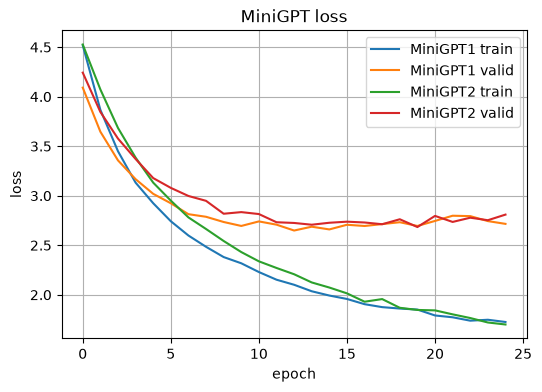

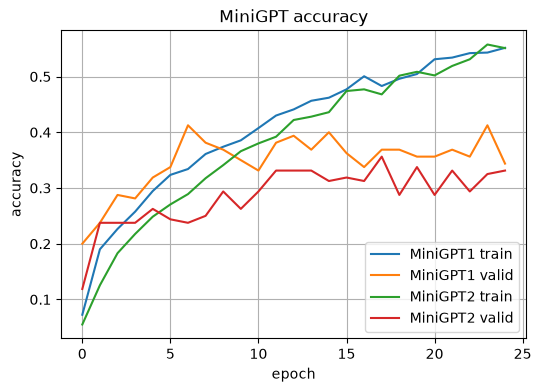

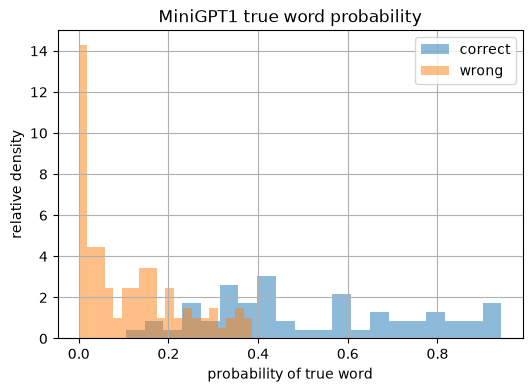

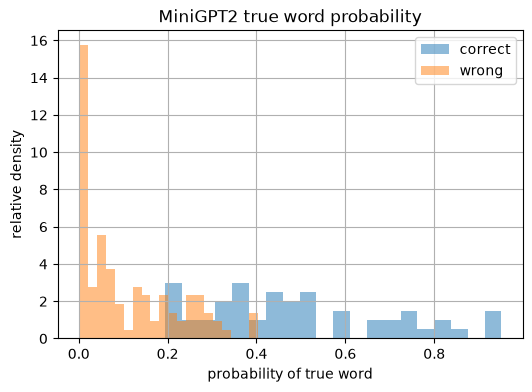

In [9]:
# Prediction
def prediction(model, data):
    model.eval()

    vprob = []
    vlabel = []
    vpred = []

    with torch.no_grad():
        for xb, yb in data:
            xb = xb.to(device)
            yb = yb.to(device)

            xb = xb[-T:]
            yb = yb[-T:]

            logits = model(xb)
            prob = F.softmax(logits, dim=-1)

            pred = prob.argmax(dim=-1)
            ptrue = prob[torch.arange(len(yb), device=device), yb]

            vprob.append(ptrue.cpu().numpy())
            vlabel.append(yb.cpu().numpy())
            vpred.append(pred.cpu().numpy())

    vprob = np.concatenate(vprob)
    vlabel = np.concatenate(vlabel)
    vpred = np.concatenate(vpred)

    return vprob, vlabel, vpred


# Loss
plt.figure(figsize=(6, 4))
plt.plot(history1["train_loss"], label="MiniGPT1 train")
plt.plot(history1["valid_loss"], label="MiniGPT1 valid")
plt.plot(history2["train_loss"], label="MiniGPT2 train")
plt.plot(history2["valid_loss"], label="MiniGPT2 valid")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("MiniGPT loss")
plt.grid(True)
plt.legend()
plt.show()


# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history1["train_acc"], label="MiniGPT1 train")
plt.plot(history1["valid_acc"], label="MiniGPT1 valid")
plt.plot(history2["train_acc"], label="MiniGPT2 train")
plt.plot(history2["valid_acc"], label="MiniGPT2 valid")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("MiniGPT accuracy")
plt.grid(True)
plt.legend()
plt.show()


# Valid prediction MiniGPT1
prob_valid1, label_valid1, pred_valid1 = prediction(model1, valid_data)

correct1 = pred_valid1 == label_valid1

plt.figure(figsize=(6, 4))
plt.hist(prob_valid1[correct1], bins=20, density=True, alpha=0.5, label="correct")
plt.hist(prob_valid1[~correct1], bins=20, density=True, alpha=0.5, label="wrong")
plt.xlabel("probability of true word")
plt.ylabel("relative density")
plt.title("MiniGPT1 true word probability")
plt.grid(True)
plt.legend()
plt.show()


# Valid prediction MiniGPT2
prob_valid2, label_valid2, pred_valid2 = prediction(model2, valid_data)

correct2 = pred_valid2 == label_valid2

plt.figure(figsize=(6, 4))
plt.hist(prob_valid2[correct2], bins=20, density=True, alpha=0.5, label="correct")
plt.hist(prob_valid2[~correct2], bins=20, density=True, alpha=0.5, label="wrong")
plt.xlabel("probability of true word")
plt.ylabel("relative density")
plt.title("MiniGPT2 true word probability")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# Generate text
def generate(model, text, n=5):
    model.eval()

    # Check input words
    for word in text.split():
        if word not in word_to_id:
            raise ValueError(f"Unknown word: {word}")

    ids = encode(text)

    with torch.no_grad():
        for _ in range(n):
            # Keep only last T words
            ctx = ids[-T:]

            x = torch.tensor(ctx, dtype=torch.long, device=device)

            # Model prediction
            logits = model(x)

            # Last position predicts next word
            last_logits = logits[-1]

            # Greedy choice
            next_id = torch.argmax(last_logits).item()

            # Add predicted word
            ids.append(next_id)

    return decode(ids)

In [11]:
# Tests MiniGPT1
print(generate(model1, "je garde", n=8))
print(generate(model1, "il marche sans", n=8))
print(generate(model1, "le courage", n=8))

# Tests MiniGPT2
print(generate(model2, "je garde", n=8))
print(generate(model2, "il marche sans", n=8))
print(generate(model2, "le courage", n=8))

je garde le courage quand le silence pese notre espoir
il marche sans peur avec un courage calme la force reste
le courage revient encore quand la nuit tombe la nuit
je garde le courage quand le doute parle le coeur
il marche sans peur vers la lumiere claire notre force reste
le courage devient grand quand la route tremble la peur
